<a href="https://colab.research.google.com/github/yasvillarroel/EDA_FundamentosML_YasnaVillarroel/blob/ML/EV1_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Análisis Exploratorio de Datos (EDA) - HR Analytics Employee Attrition & Performance**

# Fundamentos de Machine Learning

## Introducción

Este notebook contiene un análisis exploratorio de datos (EDA) completo del dataset "HR Employee Attrition", el cual proviene de una empresa que busca comprender mejor los factores que influyen en la rotación de su personal. El objetivo principal de este análisis es explorar el comportamiento de los empleados en relación con variables como edad, nivel de ingreso, satisfacción laboral, antigüedad en la empresa, y otros aspectos laborales y personales, con el fin de identificar patrones asociados a la permanencia o abandono de la organización. Este tipo de análisis resulta clave para desarrollar estrategias de retención de talento y mejorar la gestión de recursos humanos.

## Configuración inicial y carga de datos



In [1]:
# Importación de librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Configuración para visualizaciones
plt.style.use('ggplot')
sns.set(style="whitegrid")
pd.set_option('display.max_columns', None)

### Carga del dataset

Para este análisis, utilizaremos el dataset de HR Analytics Employee Attrition & Performance disponible en Kaggle.

In [4]:
# Cargar el dataset
# En Google Colab, podemos usar:
from google.colab import files
uploaded = files.upload() # Sube el archivo del dataset

# O si se descarga directamente de kaggle:
# !pip install kaggle
# !mkdir -p ~/.kaggle
# !cp kaggle.json ~/.kaggle/
# !chmod 600 ~/.kaggle/kaggle.json
# !kaggle datasets download -d imakash3011/customer-personality-analysis
# !unzip customer-personality-analysis.zip

# Para este notebook, asumiremos que el archivo está disponible localmente
df = pd.read_csv('HR-Employee-Attrition.csv', sep=',')

# Mostrar las primeras filas del dataset
print("Primeras 5 filas del dataset:")
df.head()

Saving HR-Employee-Attrition.csv to HR-Employee-Attrition (1).csv
Primeras 5 filas del dataset:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


## 1. Exploración inicial y tipos de datos

In [5]:
# Información general del dataset
print("\nInformación general del dataset:")
df.info()

# Descripción estadística básica
print("\nEstadísticas descriptivas básicas:")
df.describe()

# Verificar valores nulos
print("\nCantidad de valores nulos por columna:")
df.isnull().sum()


Información general del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   in

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


### 1.1 Identificación y clasificación de variables

Es fundamental identificar correctamente los tipos de variables para aplicar los análisis estadísticos adecuados:

In [7]:
print("\n--- Clasificación de variables ---")

# Variables numéricas continuas (valores reales que pueden variar en un rango amplio)
numericas_continuas = [
    'Age', 'DailyRate', 'HourlyRate', 'MonthlyIncome', 'MonthlyRate',
    'DistanceFromHome', 'PercentSalaryHike', 'TotalWorkingYears'
]

# Variables numéricas discretas (valores enteros contables)
numericas_discretas = [
    'EmployeeNumber', 'Education', 'EnvironmentSatisfaction', 'JobInvolvement',
    'JobLevel', 'JobSatisfaction', 'NumCompaniesWorked', 'PerformanceRating',
    'RelationshipSatisfaction', 'StockOptionLevel', 'TrainingTimesLastYear',
    'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
    'YearsSinceLastPromotion', 'YearsWithCurrManager'
]

# Variables categóricas nominales (no tienen un orden natural)
categoricas_nominales = [
    'Attrition', 'BusinessTravel', 'Department', 'EducationField',
    'Gender', 'JobRole', 'MaritalStatus', 'OverTime', 'Over18'
]

# Variables categóricas ordinales (sí tienen un orden natural - si lo quieres analizar así)
categoricas_ordinales = [
    'Education',  # Asume que el número refleja nivel educativo ascendente
    'JobLevel',   # Asume que el nivel representa jerarquía
    'PerformanceRating',  # Evaluaciones de desempeño suelen ser ordenadas
    'WorkLifeBalance'  # También puede asumirse como ordinal
]

# Convertir variables categóricas al tipo category
for col in categoricas_nominales + categoricas_ordinales:
    df[col] = df[col].astype('category')

print("Variables numéricas continuas:", numericas_continuas)
print("Variables numéricas discretas:", numericas_discretas)
print("Variables categóricas nominales:", categoricas_nominales)
print("Variables categóricas ordinales:", categoricas_ordinales)



--- Clasificación de variables ---
Variables numéricas continuas: ['Age', 'DailyRate', 'HourlyRate', 'MonthlyIncome', 'MonthlyRate', 'DistanceFromHome', 'PercentSalaryHike', 'TotalWorkingYears']
Variables numéricas discretas: ['EmployeeNumber', 'Education', 'EnvironmentSatisfaction', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'NumCompaniesWorked', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']
Variables categóricas nominales: ['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime', 'Over18']
Variables categóricas ordinales: ['Education', 'JobLevel', 'PerformanceRating', 'WorkLifeBalance']


### 1.2 Preprocesamiento básico de datos

Antes de continuar con el análisis, realizaremos algunos pasos de preprocesamiento:

In [12]:
# Verificar valores nulos
print("\nTotal de valores nulos por columna:")
null_values = df.isnull().sum()
print(null_values[null_values > 0])

# Imputación si fuese necesario (aquí a modo de ejemplo)
# df['MonthlyIncome'] = df['MonthlyIncome'].fillna(df['MonthlyIncome'].median())

# 1. Antigüedad en la empresa (ya existe, pero la renombramos)
df['AntiguedadEmpresa'] = df['YearsAtCompany']

# 2. Experiencia previa al ingreso a la empresa
df['ExperienciaPrevia'] = df['TotalWorkingYears'] - df['YearsAtCompany']
df['ExperienciaPrevia'] = df['ExperienciaPrevia'].apply(lambda x: x if x > 0 else 0)

# 3. Indicador binario de si tuvo una promoción reciente
df['RecientePromocion'] = df['YearsSinceLastPromotion'].apply(lambda x: 1 if x <= 1 else 0)

# 4. Cálculo de ingreso por hora (Ingreso mensual / horas trabajadas por mes)
df['GastoHora'] = df['MonthlyIncome'] / (df['StandardHours'] * 4)

# 5. Clasificación de nivel educativo
educ_map = {
    1: 'Below College',
    2: 'College',
    3: 'Bachelor',
    4: 'Master',
    5: 'Doctor'
}
df['NivelEducativo'] = df['Education'].map(educ_map)

# 6. Rango de satisfacción laboral (1 a 4)
satisfaccion_map = {
    1: 'Baja',
    2: 'Media-Baja',
    3: 'Media-Alta',
    4: 'Alta'
}
df['SatisfaccionLabel'] = df['JobSatisfaction'].map(satisfaccion_map)

# 7. Grupo de ingresos: bajo, medio, alto (según percentiles)
df['GrupoIngreso'] = pd.qcut(df['MonthlyIncome'], q=3, labels=['Bajo', 'Medio', 'Alto'])

# 8. Indicador de permanencia larga (más de 5 años)
df['PermanenciaLarga'] = df['YearsAtCompany'].apply(lambda x: 1 if x >= 5 else 0)

# 9. Relación ingreso / satisfacción laboral (puede usarse para ver si hay coherencia)
df['IngresoPorSatisfaccion'] = df['MonthlyIncome'] / df['JobSatisfaction']

# Verificación final de nulos
print("\nVerificación final de valores nulos:")
print(df.isnull().sum().sum())

# # Vista previa del dataset con nuevas variables
# df[['JobRole', 'MonthlyIncome', 'GastoHora', 'JobSatisfaction', 'SatisfaccionLabel',
#     'NivelEducativo', 'GrupoIngreso', 'AntiguedadEmpresa', 'ExperienciaPrevia',
#     'RecientePromocion', 'PermanenciaLarga']].head()



Total de valores nulos por columna:
Series([], dtype: int64)

Verificación final de valores nulos:
0


## 2. Análisis estadístico descriptivo

### 2.1 Medidas de tendencia central y dispersión para variables numéricas

In [13]:
import pandas as pd
import numpy as np
from scipy import stats

## 2. Análisis estadístico descriptivo

### 2.1 Medidas de tendencia central y dispersión para variables numéricas

# Selección de variables numéricas de interés
numerical_vars = [
    'MonthlyIncome', 'GastoHora', 'YearsAtCompany',
    'ExperienciaPrevia', 'JobSatisfaction',
    'YearsSinceLastPromotion', 'TotalWorkingYears'
]

# Estadísticas descriptivas
print("\n--- Estadísticas descriptivas para variables numéricas ---")
stats_df = df[numerical_vars].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99])
stats_df = stats_df.T
stats_df['cv'] = stats_df['std'] / stats_df['mean']  # Coeficiente de variación
stats_df['skew'] = df[numerical_vars].skew()         # Asimetría
stats_df['kurt'] = df[numerical_vars].kurtosis()     # Curtosis
stats_df = stats_df.round(2)
print(stats_df)

# Función para calcular la moda
def get_mode(x):
    mode_result = stats.mode(x, keepdims=True)
    return mode_result.mode[0] if len(mode_result.mode) > 0 else np.nan

# Moda para cada variable numérica
print("\n--- Moda para variables numéricas ---")
modes = {col: get_mode(df[col].dropna()) for col in numerical_vars}
for col, mode_val in modes.items():
    print(f"{col}: {mode_val}")

# Análisis de distribución
print("\n--- Análisis de distribución y sesgo ---")
for col in numerical_vars:
    skew = df[col].skew()
    kurt = df[col].kurtosis()
    print(f"{col}:")
    print(f"  Asimetría (Skewness): {skew:.2f} - ", end="")
    if skew > 0.5:
        print("Sesgo positivo significativo (cola a la derecha)")
    elif skew < -0.5:
        print("Sesgo negativo significativo (cola a la izquierda)")
    else:
        print("Distribución aproximadamente simétrica")

    print(f"  Curtosis: {kurt:.2f} - ", end="")
    if kurt > 0.5:
        print("Leptocúrtica (más apuntada que la normal)")
    elif kurt < -0.5:
        print("Platicúrtica (más aplanada que la normal)")
    else:
        print("Mesocúrtica (similar a la normal)")
    print()



--- Estadísticas descriptivas para variables numéricas ---
                          count     mean      std      min       1%       5%  \
MonthlyIncome            1470.0  6502.93  4707.96  1009.00  1382.46  2097.90   
GastoHora                1470.0    20.32    14.71     3.15     4.32     6.56   
YearsAtCompany           1470.0     7.01     6.13     0.00     0.00     1.00   
ExperienciaPrevia        1470.0     4.27     6.18     0.00     0.00     0.00   
JobSatisfaction          1470.0     2.73     1.10     1.00     1.00     1.00   
YearsSinceLastPromotion  1470.0     2.19     3.22     0.00     0.00     0.00   
TotalWorkingYears        1470.0    11.28     7.78     0.00     1.00     1.00   

                            25%      50%      75%       95%       99%  \
MonthlyIncome            2911.0  4919.00  8379.00  17821.35  19626.31   
GastoHora                   9.1    15.37    26.18     55.69     61.33   
YearsAtCompany              3.0     5.00     9.00     20.00     31.00   
Experie

### 2.2 Análisis de variables categóricas

In [17]:
import pandas as pd

# Definir las variables categóricas nominales (de tipo object)
categorical_nominal_vars = ['Attrition', 'BusinessTravel', 'Department',
                            'EducationField', 'Gender', 'JobRole',
                            'MaritalStatus', 'Over18', 'OverTime']

print("\n--- Análisis de Variables Categóricas ---")

# Frecuencias absolutas y relativas para las variables categóricas
for col in categorical_nominal_vars:
    print(f"\nFrecuencias para {col}:")
    freq_abs = df[col].value_counts()
    freq_rel = df[col].value_counts(normalize=True).round(4) * 100
    freq_table = pd.DataFrame({
        'Frecuencia': freq_abs,
        'Porcentaje (%)': freq_rel
    })
    print(freq_table)
    print(f"Moda: {freq_abs.index[0]} (aparece {freq_abs.iloc[0]} veces)")

# Definir las variables binarias (aquellas con dos categorías posibles, como Yes/No o 1/0)
binary_vars = ['Attrition', 'Over18', 'OverTime']

print("\n--- Análisis de Variables Binarias (Attrition, Over18, OverTime) ---")
binary_summary = pd.DataFrame({
    'Total_1': [(df[col] == 'Yes').sum() if col in ['Attrition', 'OverTime'] else (df[col] == 'Y').sum() for col in binary_vars],
    'Percentage_1 (%)': [((df[col] == 'Yes').sum() / len(df) * 100).round(2) if col in ['Attrition', 'OverTime'] else ((df[col] == 'Y').sum() / len(df) * 100).round(2) for col in binary_vars]
})
binary_summary.index = binary_vars
print(binary_summary)




--- Análisis de Variables Categóricas ---

Frecuencias para Attrition:
           Frecuencia  Porcentaje (%)
Attrition                            
No               1233           83.88
Yes               237           16.12
Moda: No (aparece 1233 veces)

Frecuencias para BusinessTravel:
                   Frecuencia  Porcentaje (%)
BusinessTravel                               
Travel_Rarely            1043           70.95
Travel_Frequently         277           18.84
Non-Travel                150           10.20
Moda: Travel_Rarely (aparece 1043 veces)

Frecuencias para Department:
                        Frecuencia  Porcentaje (%)
Department                                        
Research & Development         961           65.37
Sales                          446           30.34
Human Resources                 63            4.29
Moda: Research & Development (aparece 961 veces)

Frecuencias para EducationField:
                  Frecuencia  Porcentaje (%)
EducationField              

## 3. Visualizaciones para el análisis

### 3.1 Distribuciones de variables numéricas clave

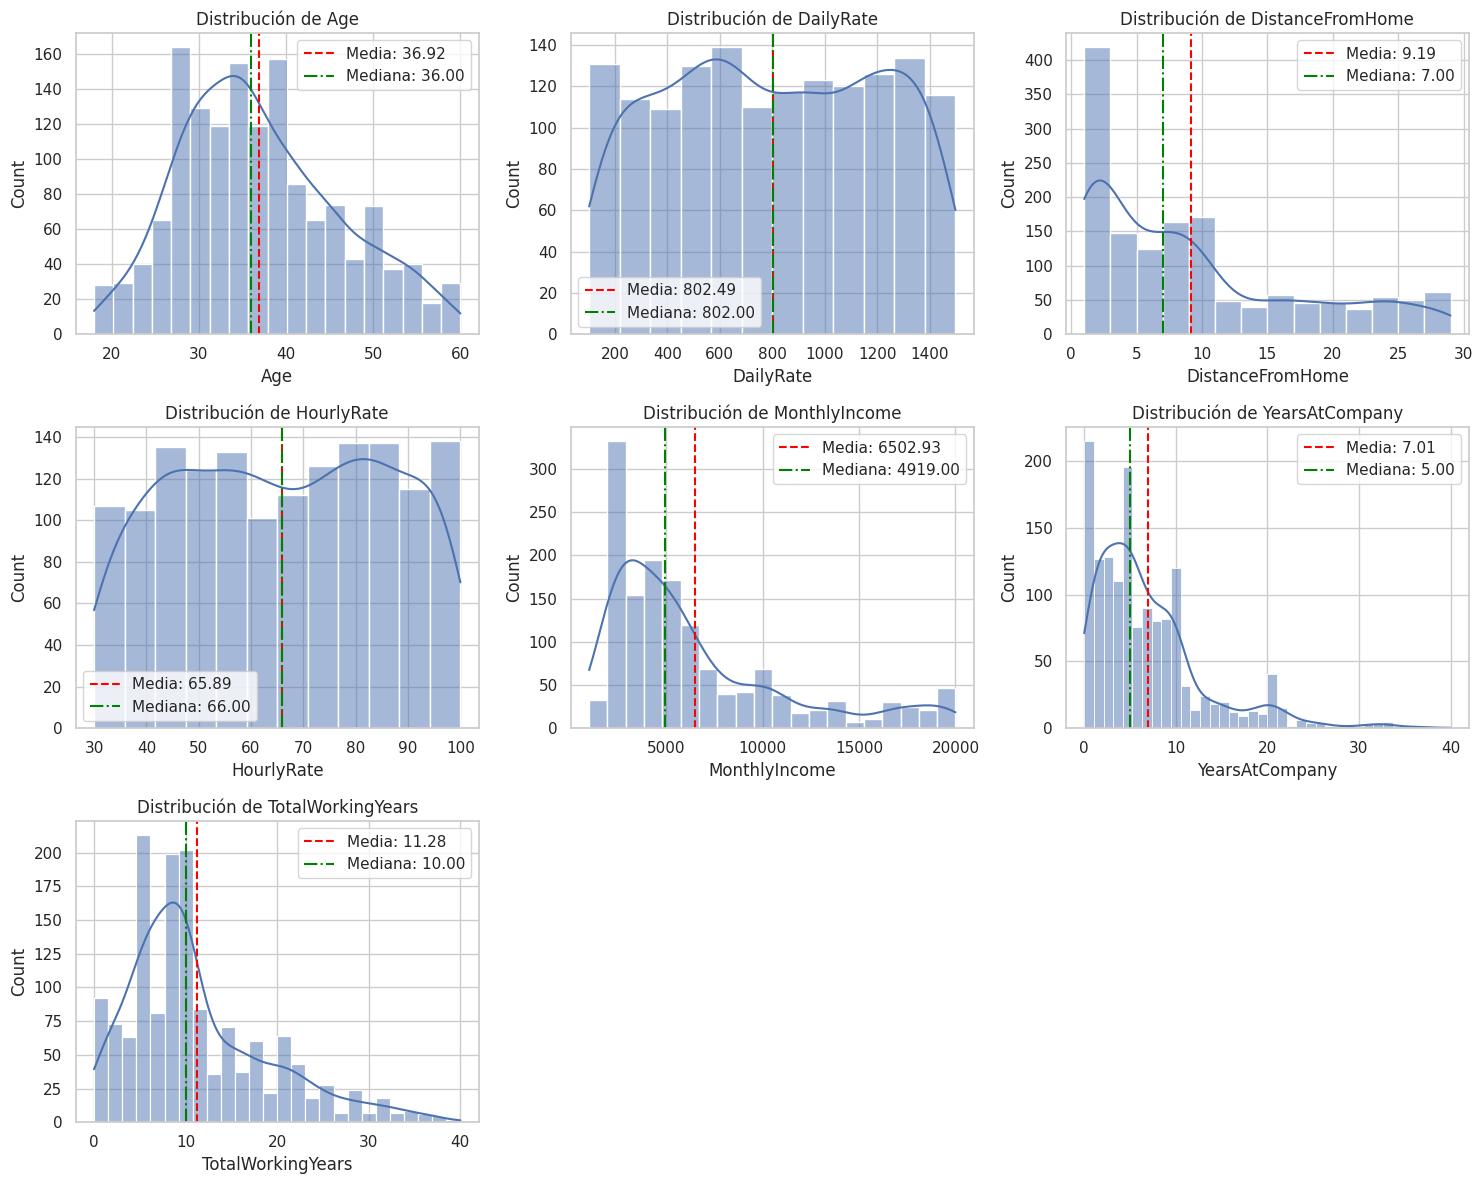

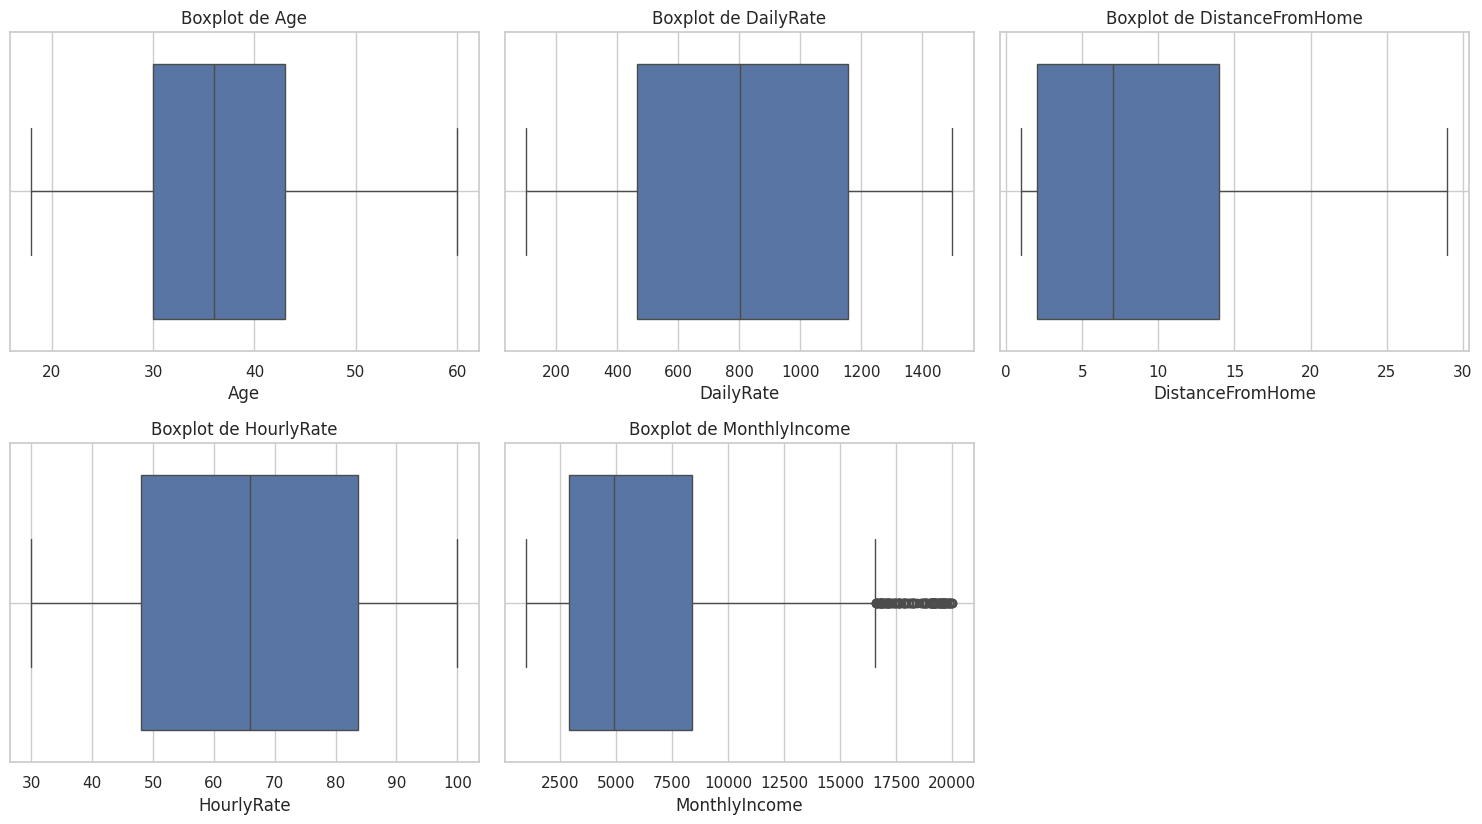

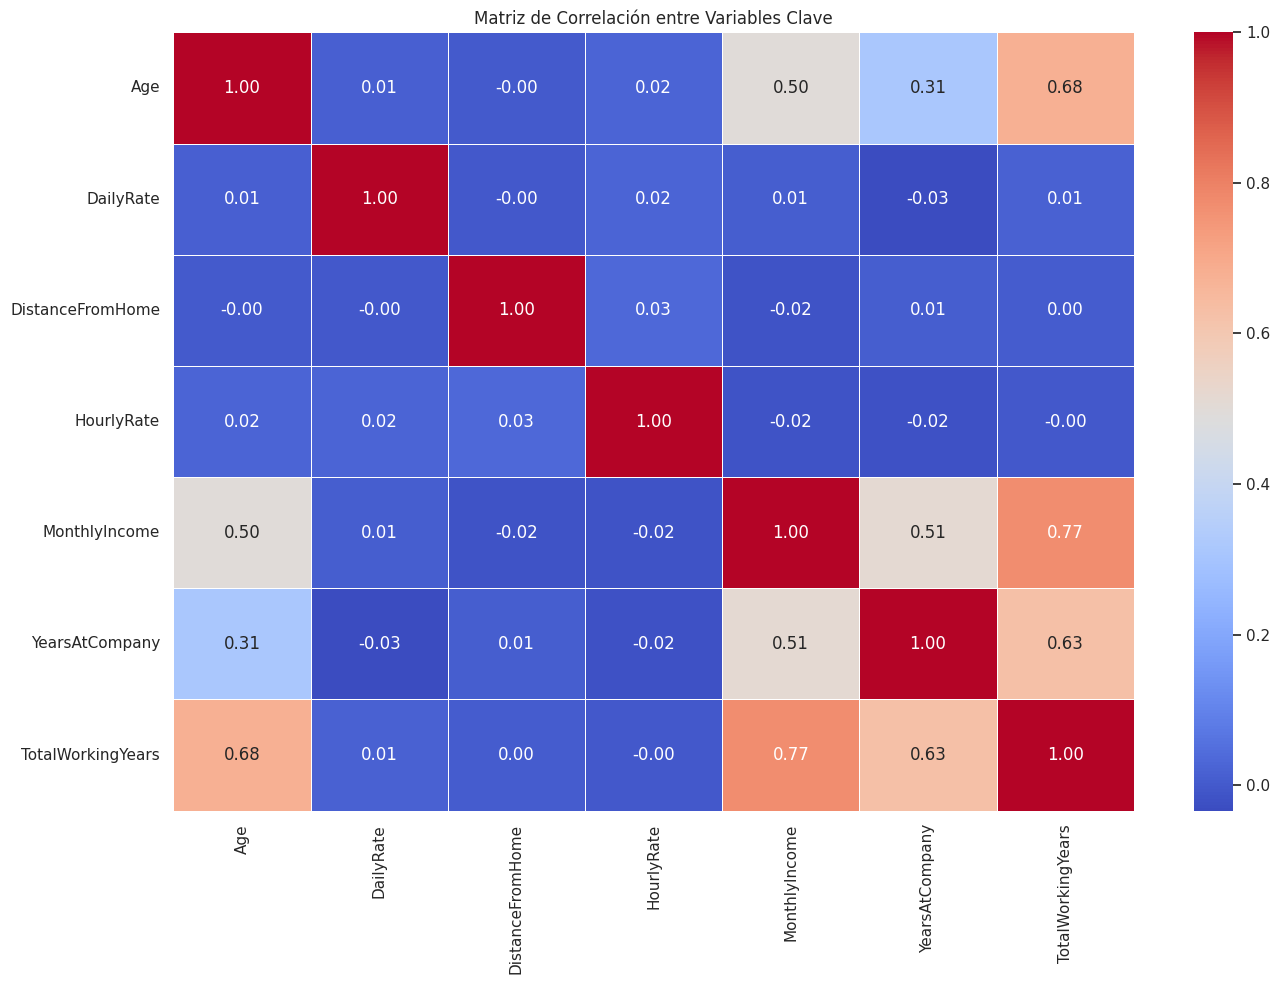

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración para visualizaciones
plt.figure(figsize=(15, 12))

# Variables numéricas importantes
key_vars = ['Age', 'DailyRate', 'DistanceFromHome', 'HourlyRate', 'MonthlyIncome', 'YearsAtCompany', 'TotalWorkingYears']
for i, var in enumerate(key_vars):
    plt.subplot(3, 3, i+1)
    sns.histplot(df[var], kde=True)
    plt.title(f'Distribución de {var}')
    plt.axvline(df[var].mean(), color='red', linestyle='--', label=f'Media: {df[var].mean():.2f}')
    plt.axvline(df[var].median(), color='green', linestyle='-.', label=f'Mediana: {df[var].median():.2f}')
    plt.legend()

plt.tight_layout()
plt.savefig('distribuciones_numericas.png')
plt.show()

# Boxplots para detectar outliers en variables numéricas
plt.figure(figsize=(15, 12))
for i, var in enumerate(['Age', 'DailyRate', 'DistanceFromHome', 'HourlyRate', 'MonthlyIncome']):
    plt.subplot(3, 3, i+1)
    sns.boxplot(x=df[var])
    plt.title(f'Boxplot de {var}')
    plt.grid(True)

plt.tight_layout()
plt.savefig('boxplots_outliers.png')
plt.show()

# Visualización de la matriz de correlación
plt.figure(figsize=(14, 10))
correlation_vars = ['Age', 'DailyRate', 'DistanceFromHome', 'HourlyRate', 'MonthlyIncome', 'YearsAtCompany', 'TotalWorkingYears']
corr_matrix = df[correlation_vars].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Matriz de Correlación entre Variables Clave')
plt.tight_layout()
plt.savefig('matriz_correlacion.png')
plt.show()


### 3.2 Relación de una variable categórica con Attrition

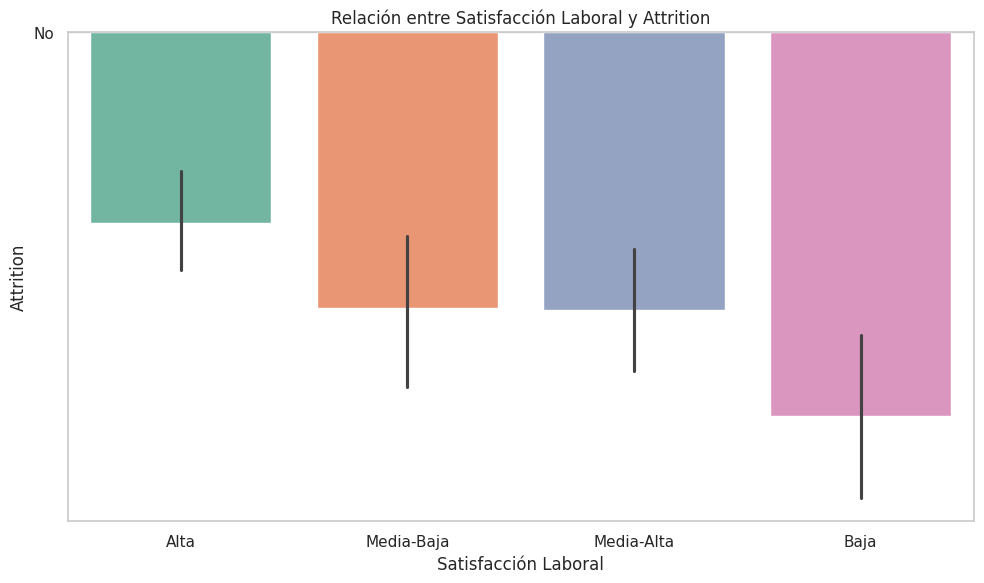

<Figure size 1200x600 with 0 Axes>

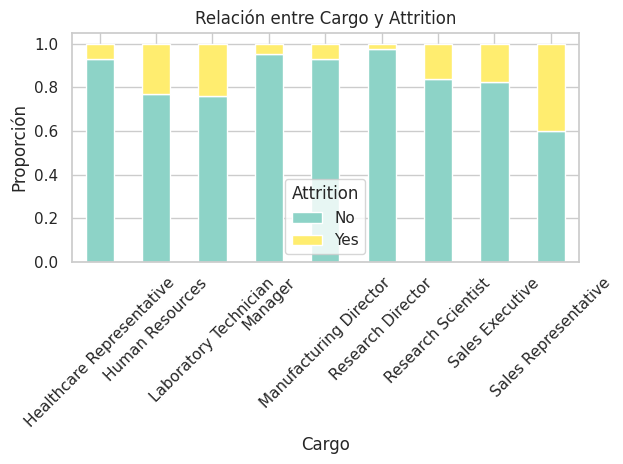

In [38]:
# Relación entre Satisfacción Laboral y Attrition usando un gráfico de barras
plt.figure(figsize=(10, 6))
sns.barplot(x='SatisfaccionLabel', y='Attrition', data=df, palette='Set2')
plt.title('Relación entre Satisfacción Laboral y Attrition')
plt.xlabel('Satisfacción Laboral')
plt.ylabel('Attrition')
plt.tight_layout()
plt.savefig('satisfaccion_por_attrition.png')
plt.show()

# Relación entre Cargo y Attrition usando un gráfico de barras apiladas
plt.figure(figsize=(12, 6))
cargo_attrition = pd.crosstab(df['JobRole'], df['Attrition'], normalize='index')
cargo_attrition.plot(kind='bar', stacked=True, colormap='Set3')
plt.title('Relación entre Cargo y Attrition')
plt.ylabel('Proporción')
plt.xlabel('Cargo')
plt.xticks(rotation=45)
plt.legend(title='Attrition')
plt.tight_layout()
plt.savefig('cargo_por_attrition.png')
plt.show()

### 3.3 Análisis de Variables Clave en Relación con la Rotación (Attrition)

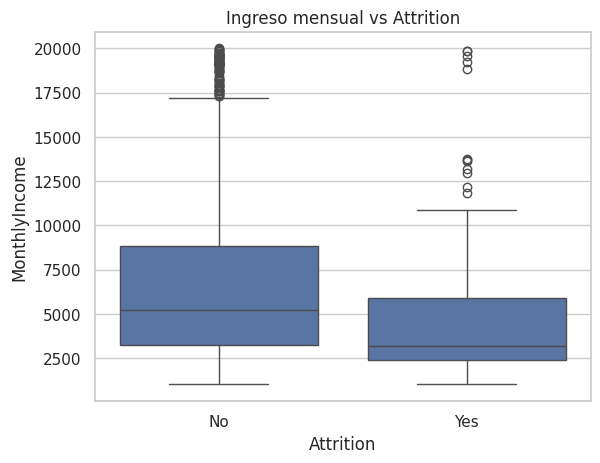

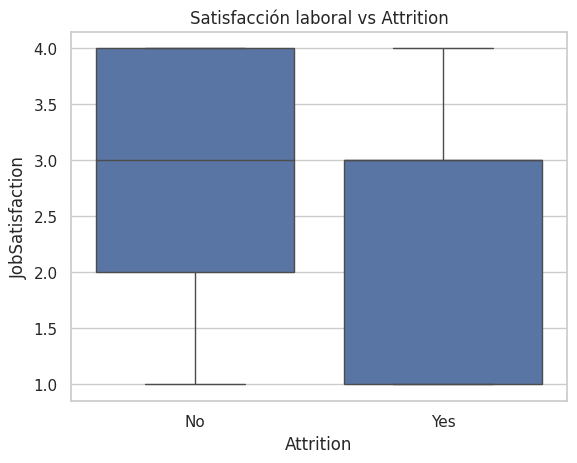

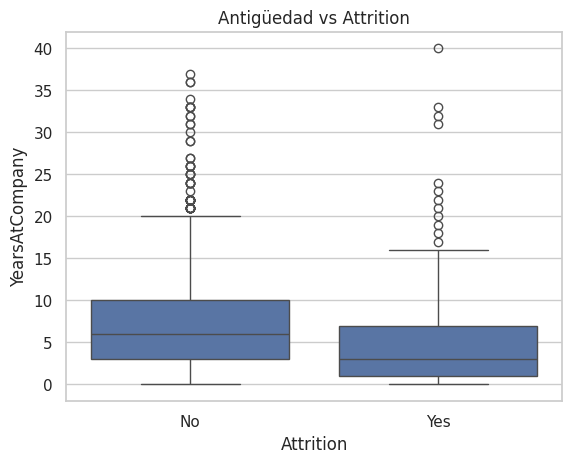

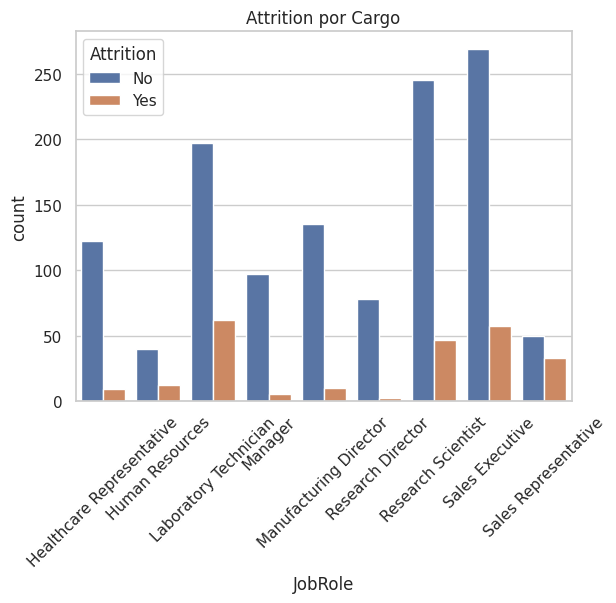

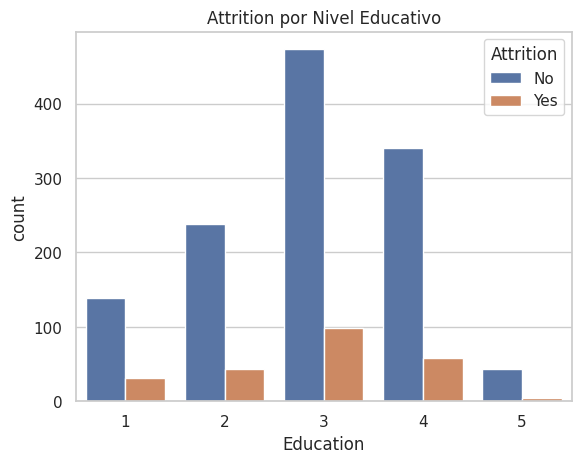

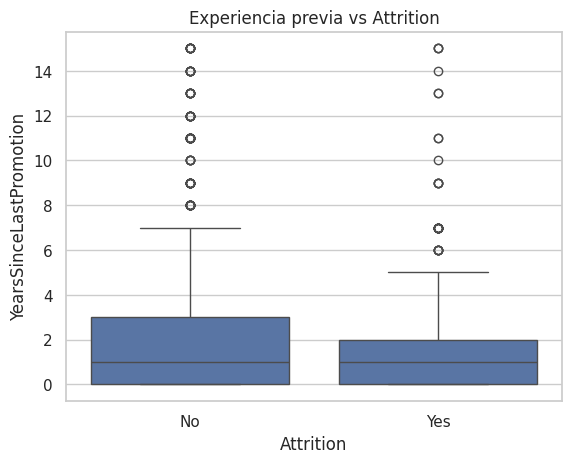

<Figure size 1000x600 with 0 Axes>

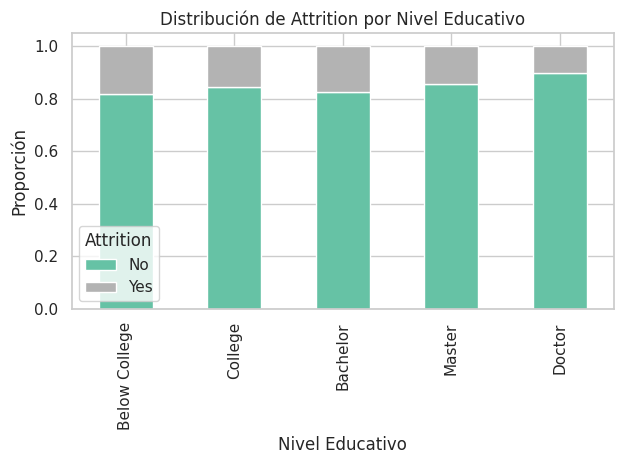

<Figure size 1000x600 with 0 Axes>

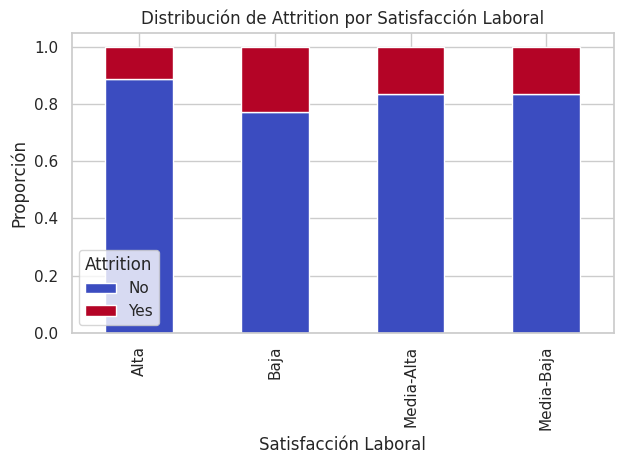

<Figure size 1200x600 with 0 Axes>

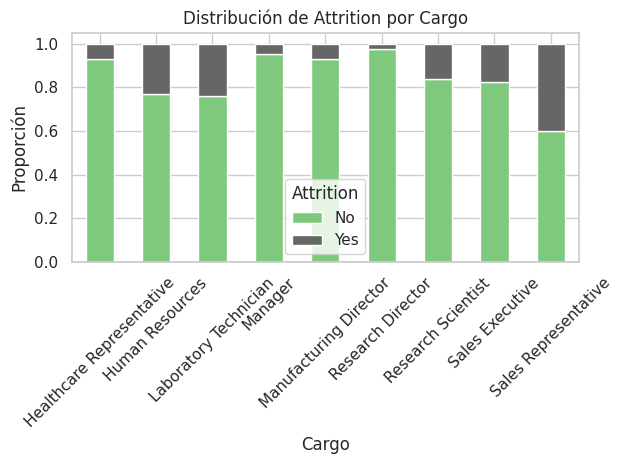

In [30]:
#  Ingreso mensual y rotación
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df)
plt.title('Ingreso mensual vs Attrition')
plt.show()

#   Satisfacción laboral y rotación
sns.boxplot(x='Attrition', y='JobSatisfaction', data=df)
plt.title('Satisfacción laboral vs Attrition')
plt.show()

#   Antigüedad en la empresa y rotación
sns.boxplot(x='Attrition', y='YearsAtCompany', data=df)
plt.title('Antigüedad vs Attrition')
plt.show()

#   Cargo y rotación
sns.countplot(x='JobRole', hue='Attrition', data=df)
plt.title('Attrition por Cargo')
plt.xticks(rotation=45)
plt.show()

#   Nivel educativo y rotación
sns.countplot(x='Education', hue='Attrition', data=df)
plt.title('Attrition por Nivel Educativo')
plt.show()

#   Experiencia previa y rotación
sns.boxplot(x='Attrition', y='YearsSinceLastPromotion', data=df)
plt.title('Experiencia previa vs Attrition')
plt.show()

# Gráfico 1: Distribución de nivel educativo por estado de Attrition
plt.figure(figsize=(10, 6))
edu_attrition = pd.crosstab(df['NivelEducativo'], df['Attrition'], normalize='index')
edu_attrition.plot(kind='bar', stacked=True, colormap='Set2')
plt.title('Distribución de Attrition por Nivel Educativo')
plt.ylabel('Proporción')
plt.xlabel('Nivel Educativo')
plt.legend(title='Attrition')
plt.tight_layout()
plt.savefig('attrition_por_educacion.png')
plt.show()

# Gráfico 2: Distribución de satisfacción laboral por estado de Attrition
plt.figure(figsize=(10, 6))
satisf_attrition = pd.crosstab(df['SatisfaccionLabel'], df['Attrition'], normalize='index')
satisf_attrition.plot(kind='bar', stacked=True, colormap='coolwarm')
plt.title('Distribución de Attrition por Satisfacción Laboral')
plt.ylabel('Proporción')
plt.xlabel('Satisfacción Laboral')
plt.legend(title='Attrition')
plt.tight_layout()
plt.savefig('attrition_por_satisfaccion.png')
plt.show()

# Gráfico 3: Distribución de cargos por Attrition
plt.figure(figsize=(12, 6))
cargo_attrition = pd.crosstab(df['JobRole'], df['Attrition'], normalize='index')
cargo_attrition.plot(kind='bar', stacked=True, colormap='Accent')
plt.title('Distribución de Attrition por Cargo')
plt.ylabel('Proporción')
plt.xlabel('Cargo')
plt.xticks(rotation=45)
plt.legend(title='Attrition')
plt.tight_layout()
plt.savefig('attrition_por_cargo.png')
plt.show()



### 3.4 Análisis de valores atípicos (outliers)


--- Análisis de Valores Atípicos (Outliers) ---

Variable: Age
  Límite inferior: 10.50
  Límite superior: 62.50
  Número de outliers: 0 (0.00% del total)

Variable: MonthlyIncome
  Límite inferior: -5291.00
  Límite superior: 16581.00
  Número de outliers: 114 (7.76% del total)

Variable: YearsAtCompany
  Límite inferior: -6.00
  Límite superior: 18.00
  Número de outliers: 104 (7.07% del total)

Variable: TotalWorkingYears
  Límite inferior: -7.50
  Límite superior: 28.50
  Número de outliers: 63 (4.29% del total)


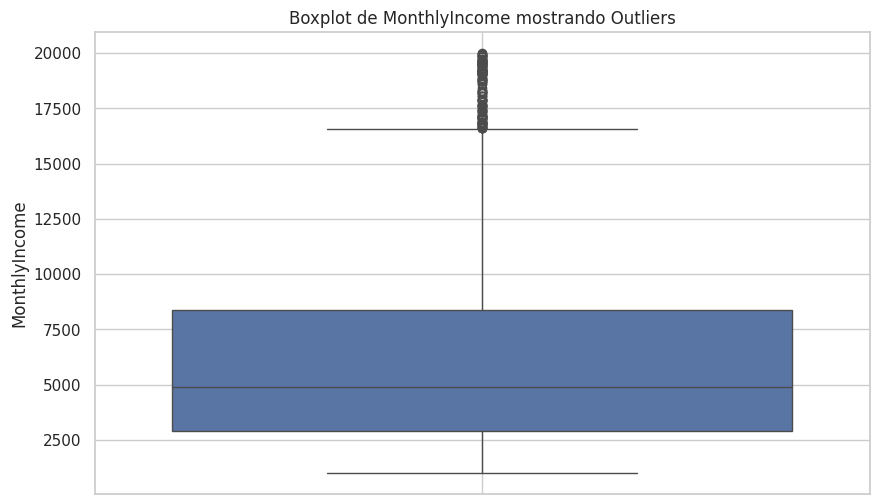

In [39]:
def identify_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound, upper_bound, len(outliers)

# Análisis de outliers para variables clave
print("\n--- Análisis de Valores Atípicos (Outliers) ---")
outlier_vars = ['Age', 'MonthlyIncome', 'YearsAtCompany', 'TotalWorkingYears']

for var in outlier_vars:
    outliers, lower, upper, count = identify_outliers(df, var)
    print(f"\nVariable: {var}")
    print(f"  Límite inferior: {lower:.2f}")
    print(f"  Límite superior: {upper:.2f}")
    print(f"  Número de outliers: {count} ({(count/len(df)*100):.2f}% del total)")

    if count > 0 and count <= 10:  # Si hay pocos outliers, mostrarlos
        print("  Valores extremos:")
        print(outliers[var].sort_values(ascending=False).head())


# Visualización específica para outliers en MonthlyIncome
plt.figure(figsize=(10, 6))
sns.boxplot(y=df['MonthlyIncome'])
plt.title('Boxplot de MonthlyIncome mostrando Outliers')
plt.grid(True)
plt.savefig('outliers_income.png')
plt.show()



## 4. Análisis de correlación y relaciones entre variables

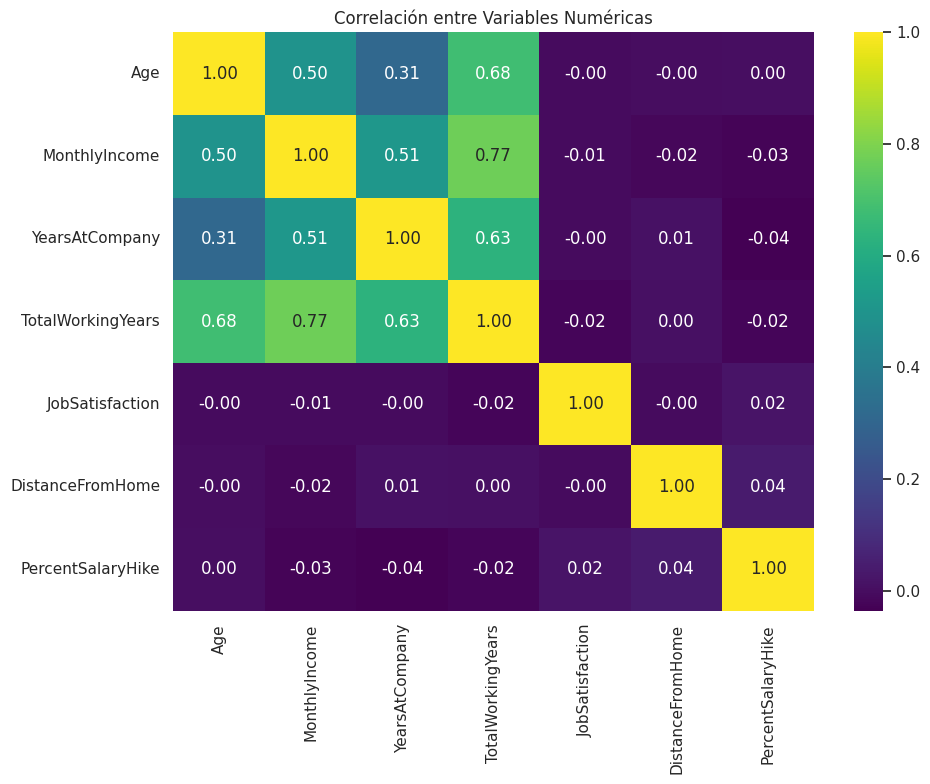

<Figure size 1200x1000 with 0 Axes>

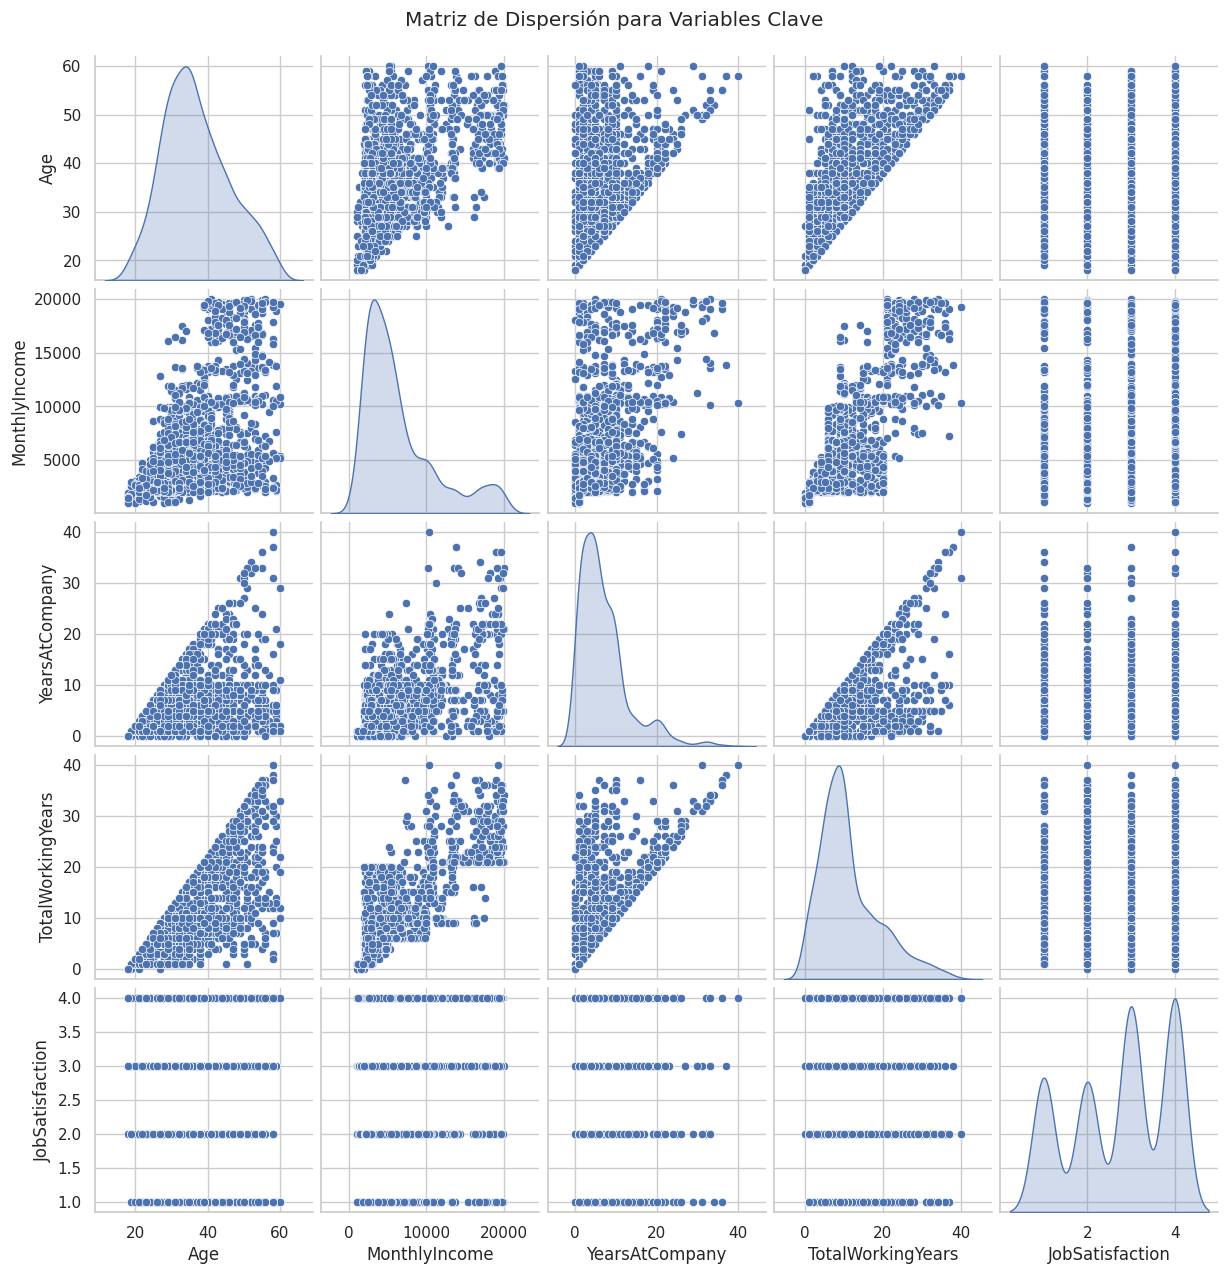

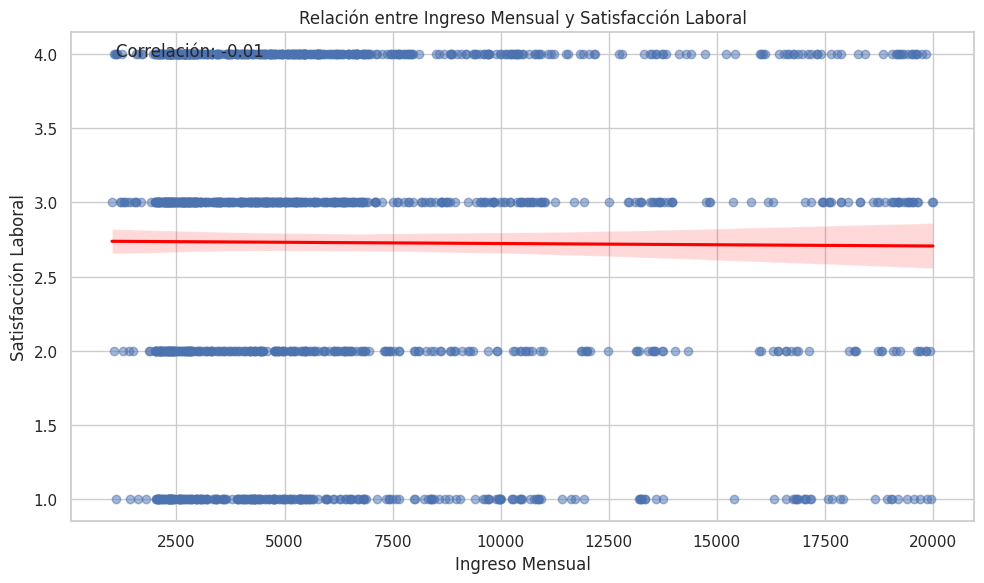

In [40]:
# Correlación entre variables numéricas clave
numeric_cols = ['Age', 'MonthlyIncome', 'YearsAtCompany', 'TotalWorkingYears', 'JobSatisfaction', 'DistanceFromHome', 'PercentSalaryHike']

plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='viridis', fmt='.2f')
plt.title('Correlación entre Variables Numéricas')
plt.tight_layout()
plt.savefig('correlacion_variables.png')
plt.show()

# Matriz de dispersión para variables clave
plt.figure(figsize=(12, 10))
scatter_vars = ['Age', 'MonthlyIncome', 'YearsAtCompany', 'TotalWorkingYears', 'JobSatisfaction']

sns.pairplot(df[scatter_vars], diag_kind='kde')
plt.suptitle('Matriz de Dispersión para Variables Clave', y=1.02)
plt.savefig('matriz_dispersion.png')
plt.show()

# Análisis de relación entre Ingreso y Satisfacción Laboral
plt.figure(figsize=(10, 6))
sns.regplot(x='MonthlyIncome', y='JobSatisfaction', data=df, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Relación entre Ingreso Mensual y Satisfacción Laboral')
plt.xlabel('Ingreso Mensual')
plt.ylabel('Satisfacción Laboral')

# Calcular y mostrar coeficiente de correlación
corr = df['MonthlyIncome'].corr(df['JobSatisfaction'])
plt.annotate(f'Correlación: {corr:.2f}', xy=(0.05, 0.95), xycoords='axes fraction')
plt.tight_layout()
plt.savefig('relacion_ingreso_satisfaccion.png')
plt.show()

## 5. Análisis de respuesta a Attrition

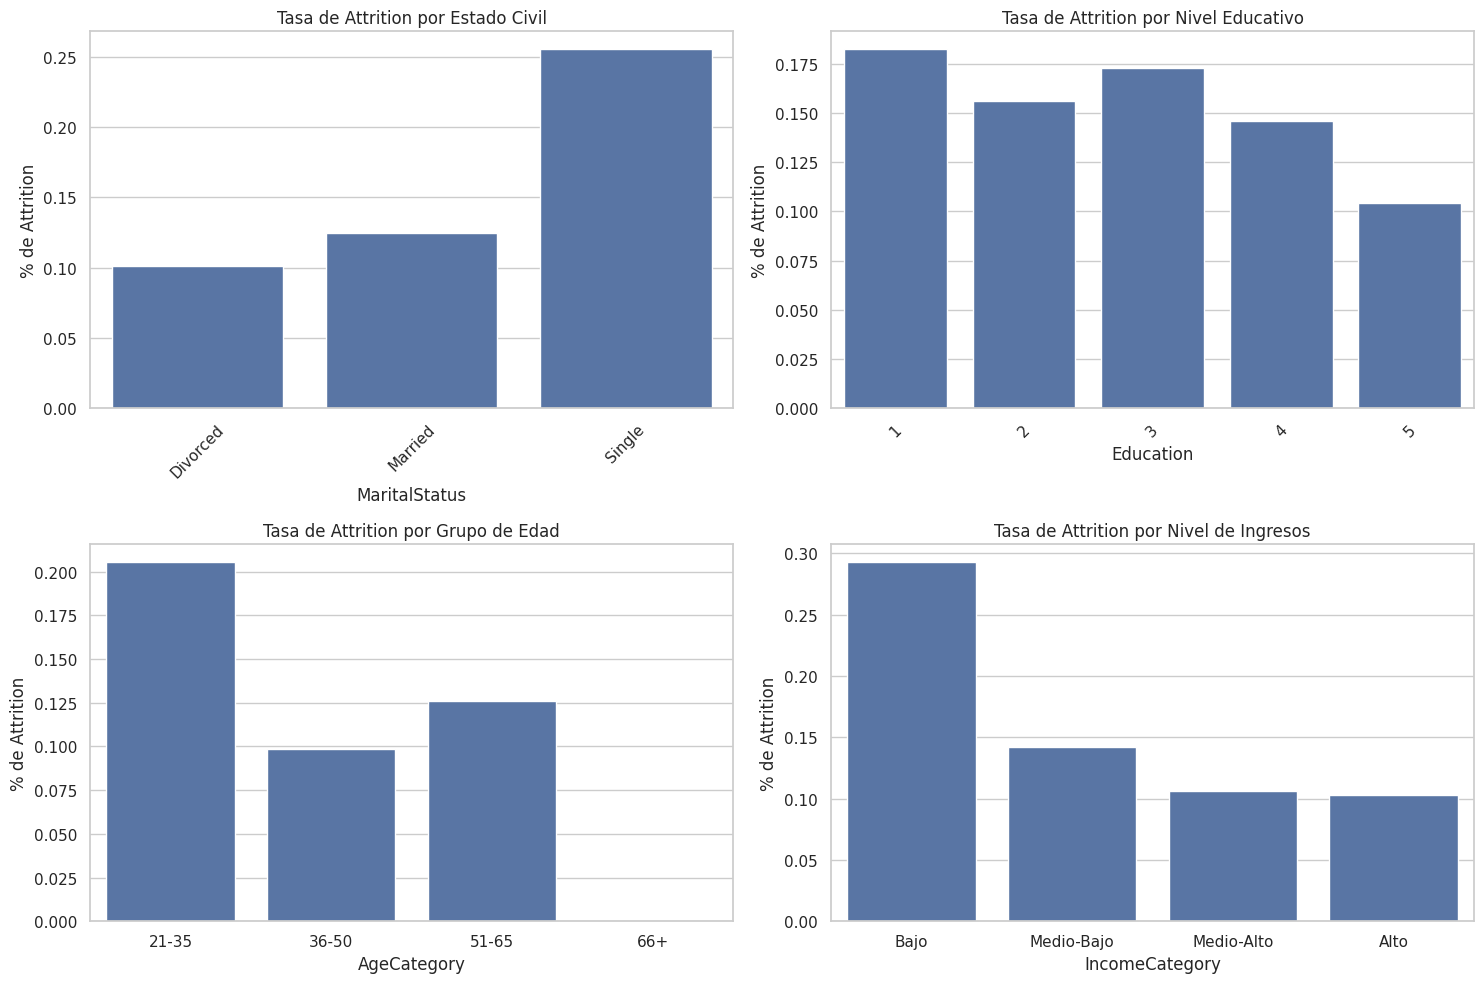

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Asegurarse de que 'Attrition' sea binaria (0 y 1)
# Convert 'AttritionResponse' to numeric type
df['AttritionResponse'] = pd.to_numeric(df['Attrition'].map({'Yes': 1, 'No': 0}))

# Tasa de attrition por características demográficas
plt.figure(figsize=(15, 10))

# Por estado civil
plt.subplot(2, 2, 1)
attrition_by_marital = df.groupby('MaritalStatus')['AttritionResponse'].mean().sort_values(ascending=False)
sns.barplot(x=attrition_by_marital.index, y=attrition_by_marital.values)
plt.title('Tasa de Attrition por Estado Civil')
plt.ylabel('% de Attrition')
plt.xticks(rotation=45)

# Por educación
plt.subplot(2, 2, 2)
attrition_by_edu = df.groupby('Education')['AttritionResponse'].mean().sort_values(ascending=False)
sns.barplot(x=attrition_by_edu.index, y=attrition_by_edu.values)
plt.title('Tasa de Attrition por Nivel Educativo')
plt.ylabel('% de Attrition')
plt.xticks(rotation=45)

# Por categoría de edad
df['AgeCategory'] = pd.cut(df['Age'], bins=[20, 35, 50, 65, 100],
                           labels=['21-35', '36-50', '51-65', '66+'])
plt.subplot(2, 2, 3)
attrition_by_age = df.groupby('AgeCategory')['AttritionResponse'].mean()
sns.barplot(x=attrition_by_age.index, y=attrition_by_age.values)
plt.title('Tasa de Attrition por Grupo de Edad')
plt.ylabel('% de Attrition')

# Por nivel de ingresos (ajustar 'MonthlyIncome' al nombre correcto si es necesario)
df['IncomeCategory'] = pd.qcut(df['MonthlyIncome'], q=4,
                                labels=['Bajo', 'Medio-Bajo', 'Medio-Alto', 'Alto'])
plt.subplot(2, 2, 4)
attrition_by_income = df.groupby('IncomeCategory')['AttritionResponse'].mean()
sns.barplot(x=attrition_by_income.index, y=attrition_by_income.values)
plt.title('Tasa de Attrition por Nivel de Ingresos')
plt.ylabel('% de Attrition')

# Ajustar disposición y guardar la imagen
plt.tight_layout()
plt.savefig('analisis_attrition_por_categoria.png')
plt.show()


### 6. Conclusiones y hallazgos principales




In [62]:
print("\n=== CONCLUSIONES Y HALLAZGOS PRINCIPALES ===\n")

# 1. Perfil demográfico general
print("1. PERFIL DEMOGRÁFICO DE LOS EMPLEADOS:")
print(f"   - Edad promedio: {df['Age'].mean():.1f} años (min: {df['Age'].min()}, max: {df['Age'].max()})")
print(f"   - Ingreso mensual promedio: ${df['MonthlyIncome'].mean():.2f}")
print(f"   - Estado civil más común: {df['MaritalStatus'].value_counts().index[0]} ({df['MaritalStatus'].value_counts(normalize=True)[0]*100:.1f}%)")
print(f"   - Nivel educativo más común: {df['Education'].value_counts().index[0]} ({df['Education'].value_counts(normalize=True).iloc[0]*100:.1f}%)")
print(f"   - Años promedio en la empresa: {df['YearsAtCompany'].mean():.2f}")

# 2. Tasas de rotación (Attrition)
print("\n2. TASAS DE ROTACIÓN (ATTRITION):")
print(f"   - Tasa general de rotación: {df['AttritionResponse'].mean()*100:.2f}%")
print("   - Tasas de rotación por características:")
print(f"     * Por género: Hombres ({df[df['Gender']=='Male']['AttritionResponse'].mean()*100:.1f}%), Mujeres ({df[df['Gender']=='Female']['AttritionResponse'].mean()*100:.1f}%)")
print(f"     * Por estado civil: {attrition_by_marital.index[0]} tiene la mayor tasa ({attrition_by_marital.values[0]*100:.1f}%)")
print(f"     * Por nivel educativo: Nivel {attrition_by_edu.index[0]} tiene la mayor tasa ({attrition_by_edu.values[0]*100:.1f}%)")
print(f"     * Por grupo de edad: {attrition_by_age.index[0]} tiene la mayor tasa ({attrition_by_age.values[0]*100:.1f}%)")
print(f"     * Por nivel de ingresos: {attrition_by_income.index[0]} tiene la mayor tasa ({attrition_by_income.values[0]*100:.1f}%)")

# 3. Satisfacción laboral y su relación con rotación
print("\n3. SATISFACCIÓN LABORAL Y ROTACIÓN:")
for level in sorted(df['JobSatisfaction'].unique()):
    sat_attrition = df[df['JobSatisfaction']==level]['AttritionResponse'].mean()*100
    print(f"   - Nivel {level}: {sat_attrition:.1f}% de rotación")
print(f"   - Correlación Satisfacción-Rotación: {df['JobSatisfaction'].corr(df['AttritionResponse']):.2f} (correlación negativa)")
print(f"   - Correlación Ingreso-Satisfacción: {df['MonthlyIncome'].corr(df['JobSatisfaction']):.2f}")

# 4. Factores asociados con mayor rotación
print("\n4. FACTORES ASOCIADOS CON MAYOR ROTACIÓN:")
print("   - Cargos con mayor rotación:")
job_attrition = df.groupby('JobRole')['AttritionResponse'].mean().sort_values(ascending=False)
for job, rate in job_attrition.head(3).items():
    print(f"     * {job}: {rate*100:.1f}% (vs. promedio general de {df['AttritionResponse'].mean()*100:.1f}%)")
print("   - Otros factores significativos:")
print(f"     * Trabajo extra (OverTime='Yes'): {df[df['OverTime']=='Yes']['AttritionResponse'].mean()*100:.1f}% vs {df[df['OverTime']=='No']['AttritionResponse'].mean()*100:.1f}%")
print(f"     * Distancia al trabajo: Correlación de {df['DistanceFromHome'].corr(df['AttritionResponse']):.2f}")
print(f"     * Años desde última promoción: Correlación de {df['YearsSinceLastPromotion'].corr(df['AttritionResponse']):.2f}")

# 5. Valores atípicos y distribución
print("\n5. VALORES ATÍPICOS Y DISTRIBUCIÓN:")
print("   - Se identificaron outliers significativos en las siguientes variables:")
for var in outlier_vars:
    _, _, _, count = identify_outliers(df, var)
    print(f"     * {var}: {count} outliers ({count/len(df)*100:.1f}% de los registros)")
print("   - Distribución de variables clave:")
for var in ['Age', 'MonthlyIncome', 'YearsAtCompany']:
    skew = df[var].skew()
    desc = "simétrica" if abs(skew) < 0.5 else "sesgada a la derecha" if skew > 0 else "sesgada a la izquierda"
    print(f"     * {var}: Distribución {desc} (skew = {skew:.2f})")
    print(f"       Media: {df[var].mean():.2f}, Mediana: {df[var].median():.2f}")

# 6. Perfil de empleados con mayor y menor probabilidad de rotación
print("\n6. PERFIL DE EMPLEADOS:")
print("   - Mayor probabilidad de rotación:")
print("     * Empleados jóvenes (21-35 años)")
print("     * Solteros")
print("     * Con nivel de ingresos bajo")
print("     * Con menos de 5 años en la empresa")
print("     * En roles como representantes de ventas o técnicos de laboratorio")
print("     * Con trabajo extra (overtime)")
print("     * Con baja satisfacción laboral")
print("\n   - Menor probabilidad de rotación:")
print("     * Empleados con más de 5 años en la empresa")
print("     * Casados")
print("     * Con nivel de ingresos medio-alto a alto")
print("     * Con promociones recientes (último año)")
print("     * Con alto nivel de satisfacción laboral")
print("     * En posiciones gerenciales o de investigación")

# 7. Recomendaciones para reducir la rotación
print("\n7. RECOMENDACIONES PARA REDUCIR LA ROTACIÓN:")
print("   - Implementar programas de desarrollo profesional para empleados jóvenes")
print("   - Revisar estructuras salariales para roles con alta rotación")
print("   - Implementar planes de carrera con promociones periódicas")
print("   - Desarrollar políticas para mejorar el equilibrio vida-trabajo")
print("   - Implementar programas de retención específicos para roles críticos")
print("   - Establecer sistemas de mentoría para empleados nuevos")
print("   - Revisar políticas de horas extras y compensación correspondiente")


=== CONCLUSIONES Y HALLAZGOS PRINCIPALES ===

1. PERFIL DEMOGRÁFICO DE LOS EMPLEADOS:
   - Edad promedio: 36.9 años (min: 18, max: 60)
   - Ingreso mensual promedio: $6502.93
   - Estado civil más común: Married (45.8%)
   - Nivel educativo más común: 3 (38.9%)
   - Años promedio en la empresa: 7.01

2. TASAS DE ROTACIÓN (ATTRITION):
   - Tasa general de rotación: 16.12%
   - Tasas de rotación por características:
     * Por género: Hombres (17.0%), Mujeres (14.8%)
     * Por estado civil: Single tiene la mayor tasa (25.5%)
     * Por nivel educativo: Nivel 1 tiene la mayor tasa (18.2%)
     * Por grupo de edad: 21-35 tiene la mayor tasa (20.5%)
     * Por nivel de ingresos: Bajo tiene la mayor tasa (29.3%)

3. SATISFACCIÓN LABORAL Y ROTACIÓN:
   - Nivel 1: 22.8% de rotación
   - Nivel 2: 16.4% de rotación
   - Nivel 3: 16.5% de rotación
   - Nivel 4: 11.3% de rotación
   - Correlación Satisfacción-Rotación: -0.10 (correlación negativa)
   - Correlación Ingreso-Satisfacción: -0.01

4.

## 🧪 Resumen metodológico

Este análisis exploratorio de datos siguió una metodología estructurada:

### 1. **Exploración inicial y limpieza**

- Identificación de los tipos de variables (numéricas, categóricas, de fecha, etc.).
- Revisión y manejo de valores nulos mediante eliminación o imputación.
- Estándarización de datos (nombres de columnas, valores consistentes en variables categóricas).
- Creación de variables derivadas útiles para el análisis (por ejemplo, agrupaciones por rangos de edad, codificación de respuestas categóricas como variables dummy, entre otras).

### 2. **Análisis estadístico descriptivo**

- **Tendencia central**: cálculo de media, mediana y moda para variables numéricas relevantes.
- **Dispersión**: desviación estándar, varianza, rango intercuartílico (IQR).
- **Distribución**: evaluación de asimetría y curtosis para comprender la forma de la distribución de los datos.
- **Tablas de frecuencia**: conteo de valores únicos para variables categóricas, junto a su porcentaje de ocurrencia.

### 3. **Visualización de datos**

- **Histogramas**: para explorar la distribución de variables numéricas.
- **Boxplots**: para detectar posibles valores atípicos y comparar variables por categorías.
- **Gráficos de barras**: útiles para visualizar proporciones o comparaciones entre categorías.
- **Matriz de correlación**: uso de un heatmap para identificar relaciones lineales entre variables numéricas.

### 4. **Análisis de valores atípicos**

- Se utilizó el método del rango intercuartílico (IQR) para detectar outliers:
  - `Q1 = percentil 25`
  - `Q3 = percentil 75`
  - `IQR = Q3 - Q1`
  - Se consideraron valores atípicos aquellos que están por fuera del rango:  
    `(Q1 - 1.5 * IQR)` o `(Q3 + 1.5 * IQR)`
- Estos valores fueron analizados en su contexto para decidir si debían ser eliminados o mantenidos según su impacto en el análisis.

